In [4]:
%load_ext autoreload
%autoreload 2

import platform
import pandas as pd
import os
import sys

system = platform.system()
if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'


try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *

home = home + 'data/confocal/'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


In [6]:

user = 'Carmina'
dates = [
   # '2026_06_05',
    '2026_06_15', 
    '2026_06_25'
    ]
csv_files = [
    #'coloc_results', #coloc_results_2_raw',#'coloc_results_2', #'coloc_results
    'coloc_results_raw',
    'coloc_results_raw',

]

rows2drop = [
           # [],
            [
                'dec02_5x_brain3gamma_R8', 
                'dec02_5x_brain4alpha_L16' 
            ],
            []
                ]



df_list = [] 
for i, date in enumerate(dates):
    path_csv = home + date + '_' + user + f'/{csv_files[i]}.csv'
    df = pd.read_csv(path_csv)

    #TO EXCLUDE SOME ROWS:
    if rows2drop[i]:
        for name in rows2drop[i]:
   
            df = df.drop(df[df["name"] == name].index).reset_index(drop=True)
    ###########
    df_list.append(df)

pooled = (
    pd.concat(df_list, keys=dates, names=["date"])
    .reset_index(level="date")      # moves 'date' level out of the index into a column
    .reset_index(drop=True)         # replaces the remaining old-index level with plain 0..n
)
print(pooled.columns)
print(pooled['date'])
print(pooled['name'])






Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       'MB_total_pearson_r HSP-Mito', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_pearson_r HSP-Mito',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_pearson_r HSP-Mito', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', '

In [7]:
#pooled[['name','MB_total_pearson_r HSP-Mito','MB_syn_pearson_r HSP-Mito','MB_non_syn_pearson_r HSP-Mito']]
#pooled[['name','MB_total_enrichment','MB_total_odds_ratio']]
#pooled[['date','name','snr_min_HSP_Mito','MB_total_enrichment','MB_total_odds_ratio']]


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito']

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap', <-----------
       'MB_non_syn_share of total HSP-Mito overlap',<-----------
       'MB_syn_HSP-Mito colocalization density',<-----------
       'MB_non_syn_HSP-Mito colocalization density',<-----------
       
       
        'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 
       
       'density_HSP_syn', <-----------
       'density_HSP_non_syn', <-----------
       'density_Mito_syn', <-----------
       'density_Mito_non_syn',<-----------
       
       
       'MB_total_fraction of HSP in Mito', 'MB_total_fraction of Mito in HSP',
       'MB_total_odds_ratio', 'MB_total_enrichment',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       
       'MB_total_pearson_r HSP-Mito', <-----------
       
       'MB_total_fraction of HSP in Mito','MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 
       
       'MB_syn_pearson_r HSP-Mito', <-----------

       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP','MB_syn_odds_ratio','MB_syn_enrichment',
       
       'MB_non_syn_pearson_r HSP-Mito', <-----------
       
       'MB_non_syn_fraction of HSP in Mito','MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

In [8]:
df_dict = df_separator(pooled)
print(df_dict.keys())
df_5x_1x = pd.concat([df_dict['5x'], df_dict['1x']], axis=1)
#df_5x_1x.head(10)
#fast_plotter(['prop_MB-HSP_in_syn'], df=df_5x_1x, ylabel='', title=title,
                        # bar_color=[['pink', 'hotpink']], quietStats=False, figsize=(6,6), legend=True)

dict_keys(['5x', '1x', '5x.alpha_', '5x.alphaprime_', '5x.gamma_', '1x.alpha_', '1x.alphaprime_', '1x.gamma_'])


   prop_MB-HSP_in_syn_5x  prop_MB-HSP_in_syn_1x
0                  0.175                  0.237
1                  0.106                  0.237
2                  0.047                  0.210
3                  0.024                  0.181
4                  0.182                  0.173
5                  0.159                  0.056
6                  0.012                  0.129
7                    NaN                  0.134
8                    NaN                  0.035
9                    NaN                  0.136
['prop_MB-HSP_in_syn_5x', 'prop_MB-HSP_in_syn_1x']

---------- STATS ----------
prop_MB-HSP_in_syn_5x
  W statistic = 0.8714
  p-value     = 0.1911
  → Data look approximately normal

prop_MB-HSP_in_syn_1x
  W statistic = 0.9269
  p-value     = 0.3489
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.1746
p-value   = 0.6813
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.7003
p-value     = 0.2096
→ No significant differen

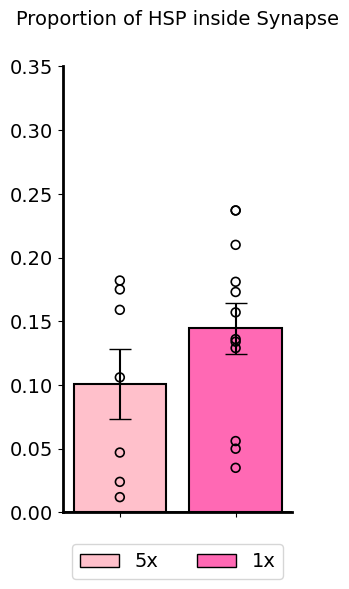

   prop_MB-Mito_in_syn_5x  prop_MB-Mito_in_syn_1x
0                   0.158                   0.252
1                   0.111                   0.232
2                   0.051                   0.198
3                   0.025                   0.199
4                   0.205                   0.181
5                   0.174                   0.013
6                   0.007                   0.124
7                     NaN                   0.129
8                     NaN                   0.024
9                     NaN                   0.133
['prop_MB-Mito_in_syn_5x', 'prop_MB-Mito_in_syn_1x']

---------- STATS ----------
prop_MB-Mito_in_syn_5x
  W statistic = 0.9232
  p-value     = 0.4946
  → Data look approximately normal

prop_MB-Mito_in_syn_1x
  W statistic = 0.8855
  p-value     = 0.1031
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0331
p-value   = 0.8578
→ Variances are not significantly different

One-way ANOVA
F statistic = 0.8769
p-value     = 0.3622

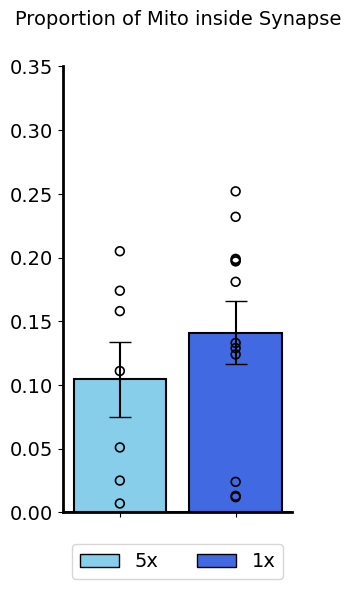

In [9]:

#colmns2plot = ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP']

#colmns2plot = ['MB_syn_enrichment','MB_non_syn_enrichment']
#colmns2plot = ['MB_syn_odds_ratio', 'MB_non_syn_odds_ratio']
#colmns2plot = ['MB_syn_share of total HSP-Mito overlap', 'MB_non_syn_share of total HSP-Mito overlap',]
#colmns2plot = ['MB_syn_HSP-Mito colocalization density','MB_non_syn_HSP-Mito colocalization density']

colmns2plot = ['prop_MB-HSP_in_syn', 
               'prop_MB-Mito_in_syn'
               ]


titles= ['Proportion of HSP inside Synapse', 
         'Proportion of Mito inside Synapse',
         ]


colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]



        
        
ks = ['5x', '1x']     
for jj, col in enumerate(colmns2plot):
    all_df = pd.DataFrame()
    col_data = {}
    new_col_list = []
    for k in ks:
        df_k = df_dict[k]
        new_col = f"{col}_{k}"
        new_col_list.append(new_col)
   
        col_data[new_col] = df_k[col].reset_index(drop=True)
        
    all_df = pd.concat(col_data, axis=1)
    print(all_df.head(10))
    print(new_col_list)

    bar_color = colors[jj]#colors[j][:len(colmns2plot)] * len(key_group)
    title = titles[jj]

    fast_plotter(new_col_list, df= all_df, ylabel='', ylim=[0,0.35], labels=ks, bar_color=bar_color, title=title,title_font_size=14, quietStats=False, figsize=(3,6), legend=True)



---------- STATS ----------
density_HSP_syn_5x
  W statistic = 0.9024
  p-value     = 0.3456
  → Data look approximately normal

density_HSP_non_syn_5x
  W statistic = 0.9540
  p-value     = 0.7661
  → Data look approximately normal

density_HSP_syn_1x
  W statistic = 0.7857
  p-value     = 0.0065
  → Significant deviation from normality

density_HSP_non_syn_1x
  W statistic = 0.8688
  p-value     = 0.0632
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9962
p-value   = 0.1331
→ Variances are not significantly different

Kruskal-Wallis test
H statistic = 3.0873
p-value     = 0.3784
→ No significant differences detected

group: 5x syn, mean: 0.12315714285714285, sem: 0.012068097596217754
group: 5x non-syn, mean: 0.09848571428571429, sem: 0.006622991288341105
group: 1x syn, mean: 0.124825, sem: 0.02263510991264623
group: 1x non-syn, mean: 0.09598333333333332, sem: 0.007097009969349804


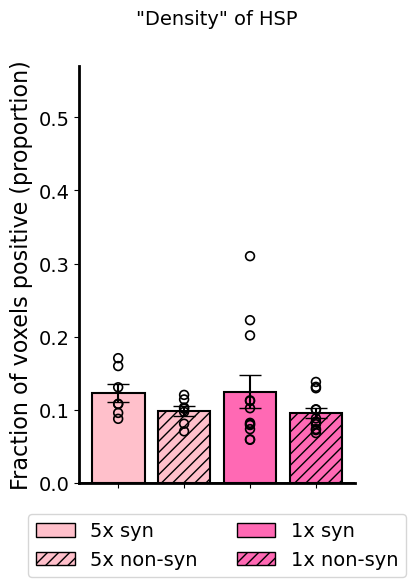


---------- STATS ----------
density_Mito_syn_5x
  W statistic = 0.9355
  p-value     = 0.5983
  → Data look approximately normal

density_Mito_non_syn_5x
  W statistic = 0.9510
  p-value     = 0.7392
  → Data look approximately normal

density_Mito_syn_1x
  W statistic = 0.9314
  p-value     = 0.3955
  → Data look approximately normal

density_Mito_non_syn_1x
  W statistic = 0.9614
  p-value     = 0.8040
  → Data look approximately normal

Brown-Forsythe test
Statistic = 5.6617
p-value   = 0.0029
→ Variances differ significantly

Kruskal-Wallis test
H statistic = 4.4640
p-value     = 0.2155
→ No significant differences detected

group: 5x syn, mean: 0.18715714285714283, sem: 0.02294592875127314
group: 5x non-syn, mean: 0.14664285714285713, sem: 0.006474192619008738
group: 1x syn, mean: 0.16561666666666666, sem: 0.023142636872537696
group: 1x non-syn, mean: 0.15335833333333332, sem: 0.003697367170014224


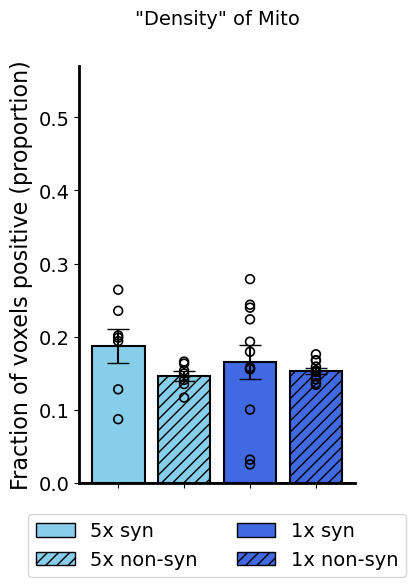

In [10]:
# density_HSP_* / density_Mito_* are defined in colocalization.py as
# (channel-positive voxels) / (voxels in that compartment) -- i.e. the fraction of
# the synaptic/non-synaptic compartment's volume that is channel-positive. That's a
# dimensionless proportion (0-1), not a physical density -- labelled accordingly below,
# and "Density" is kept in quotes in the titles for the same reason.
#
# Uses fast_plotter (not plot_bars_with_sem3) so significance testing runs
# automatically (normality/variance checks -> ANOVA+Tukey or Mann-Whitney/Kruskal as
# appropriate, with significance brackets drawn on the plot).

df_dict = df_separator(pooled)

density_ylabel = 'Fraction of voxels positive (proportion)'
bar_labels = ['5x syn', '5x non-syn', '1x syn', '1x non-syn']

def _build_all_df(col_syn, col_non_syn):
    col_data = {}
    new_col_list = []
    for k in ['5x', '1x']:
        df_k = df_dict[k]
        for col in (col_syn, col_non_syn):
            new_col = f"{col}_{k}"
            new_col_list.append(new_col)
            col_data[new_col] = df_k[col].reset_index(drop=True)
    return pd.concat(col_data, axis=1), new_col_list

all_df_hsp, cols_hsp = _build_all_df('density_HSP_syn', 'density_HSP_non_syn')
all_df_mito, cols_mito = _build_all_df('density_Mito_syn', 'density_Mito_non_syn')

# Shared y-limit across both figures: take the larger data max of the two (nanmax --
# a sample with zero synaptic or non-synaptic voxels gets NaN from colocalization.py's
# density calculation, and plain .max() would propagate that NaN into the axis limit),
# and reserve headroom using the same formula fast_plotter itself uses for
# significance brackets (data_max + 0.1 + 0.04 per bracket), capped at up to 4
# brackets so it stays correct regardless of exactly which comparisons are significant.
shared_max = max(np.nanmax(all_df_hsp[cols_hsp].to_numpy()), np.nanmax(all_df_mito[cols_mito].to_numpy()))
shared_ylim = [0, shared_max + 0.1 + 0.04 * 4]

# Figure 1: Density of HSP
fast_plotter(
    cols_hsp, df=all_df_hsp, ylabel=density_ylabel, labels=bar_labels,
    bar_color=['pink', 'pink', 'hotpink', 'hotpink'],
    pattern=['', '///', '', '///'],
    title='"Density" of HSP', figsize=(4, 6), ylim=shared_ylim,
    legend=True, quietStats=False,
)

# Figure 2: Density of Mito
fast_plotter(
    cols_mito, df=all_df_mito, ylabel=density_ylabel, labels=bar_labels,
    bar_color=['skyblue', 'skyblue', 'royalblue', 'royalblue'],
    pattern=['', '///', '', '///'],
    title='"Density" of Mito', figsize=(4, 6), ylim=shared_ylim,
    legend=True, quietStats=False,
)


## Colocalization: synapse vs non-synapse

Four figures, one per metric, each comparing `MB_syn_*` vs `MB_non_syn_*` directly.

- **Paired test** (`paired=True` -> Wilcoxon signed-rank, not the unpaired Mann-Whitney/ANOVA path): syn and non-syn values come from the *same* sample/animal, so this is a within-subject comparison, not two independent groups. This is also much better-powered than the earlier 5X-vs-1X comparisons, since pairing removes animal-to-animal variability entirely (~19 paired samples here vs 2-4 independent animals per condition there).
- **`MB_total` deliberately excluded** — it's the pooled combination of syn+non_syn from the same image, not a third independent group, so including it in the same statistical comparison would violate independence.
- **Odds ratio plotted as `log(OR)`**, per the log-scale pooling convention already established in `colocalization_metrics_explanation.md` (OR is a right-skewed ratio, null at 1 — averaging it on the raw scale is biased). Enrichment and the two fraction metrics are plotted on the raw/linear scale, consistent with that same doc.
- Training condition (5x/1x) intentionally left out here — this is the syn-vs-non-syn question on its own, pooled across condition, kept separate from the condition comparison to avoid re-importing its confounds/power problems into a currently clean comparison.

### Interpreting the log(Odds Ratio) plot

- **Zero is the reference, not an arbitrary baseline** — `log(OR=1) = 0`, and OR=1 means "no association beyond chance." The plot already draws a horizontal line at 0 (`plot_bars_with_sem3_test`'s baseline), so read each bar relative to that line:
  - **Above 0** -> OR > 1 -> that compartment shows more HSP-Mito co-occurrence than chance.
  - **At/near 0**, especially if the SEM error bar crosses the line -> not distinguishable from independence in that compartment, regardless of what the other bar shows.
  - **Below 0** -> OR < 1 -> less overlap than chance predicts (active exclusion, a different story from "no association").
- **Converting a bar height back to an actual OR**: `OR = exp(log(OR))`. E.g. a bar at 1.5 means OR ~= e^1.5 ~= 4.48 — report *this* number in text/results, not the log value itself. The log scale is for the plot and the statistics, not for reporting.
- **Why log specifically**: it turns multiplicative symmetry into additive symmetry. OR=2 and OR=0.5 are equally strong associations in opposite directions, but look wildly asymmetric on a raw scale (2 vs 0.5); on the log scale they're +0.693 and -0.693 -- equidistant from zero. This is why OR should never be averaged/plotted on its raw scale (a few large ORs would dominate a linear mean and misrepresent the "typical" effect).
- **Reading the gap between the synapse and non-synapse bars**: subtracting two log(OR) values gives `log(OR_syn / OR_non_syn)` — a **ratio**, not a difference in absolute strength. A gap of 0.7 means `OR_syn` is `e^0.7 ~= 2.0x` larger than `OR_non_syn`, i.e. colocalization strength is about twice as strong inside synapses -- not "0.7 units" stronger.
- **What the significance bracket does and doesn't tell you**: the paired Wilcoxon test compares synapse vs non-synapse *within the same samples* — a significant result means synaptic and non-synaptic OR reliably differ from each other within-brain. It does **not** tell you whether either compartment individually is significantly above chance (OR != 1) — that's answered separately by whether each bar (with its SEM) sits clearly away from the zero line.


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9025
  p-value     = 0.3467
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9849
  p-value     = 0.9799
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.2329
p-value   = 0.6380
→ Variances are not significantly different

MB_syn_fraction of HSP in Mito
  W statistic = 0.9025
  p-value     = 0.3467
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9849
  p-value     = 0.9799
  → Data look approximately normal

Paired t-test
t statistic = 2.8355
p-value     = 0.0297
→ Significant difference between groups

  Matched-pairs rank-biserial r = 0.8571
  Effect size: large

group: Synapse, mean: 0.2698571428571429, sem: 0.02787166898434303
group: Non-synapse, mean: 0.21257142857142858, sem: 0.022108883307133252


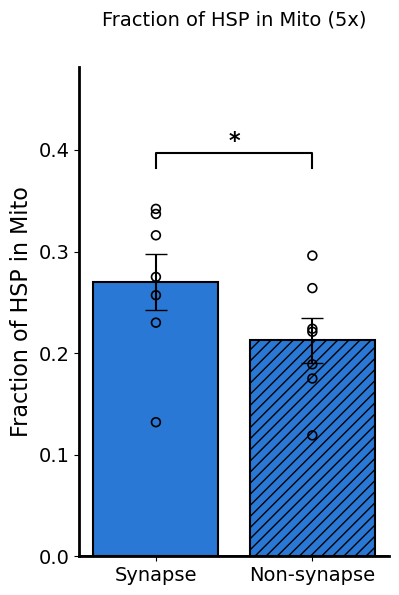


---------- STATS ----------
MB_syn_fraction of Mito in HSP
  W statistic = 0.9806
  p-value     = 0.9623
  → Data look approximately normal

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.9663
  p-value     = 0.8704
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.4985
p-value   = 0.4936
→ Variances are not significantly different

MB_syn_fraction of Mito in HSP
  W statistic = 0.9806
  p-value     = 0.9623
  → Data look approximately normal

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.9663
  p-value     = 0.8704
  → Data look approximately normal

Paired t-test
t statistic = 5.5013
p-value     = 0.0015
→ Significant difference between groups

  Matched-pairs rank-biserial r = 1.0000
  Effect size: large

group: Synapse, mean: 0.18571428571428572, sem: 0.02410267154300958
group: Non-synapse, mean: 0.14342857142857143, sem: 0.01709616657513098


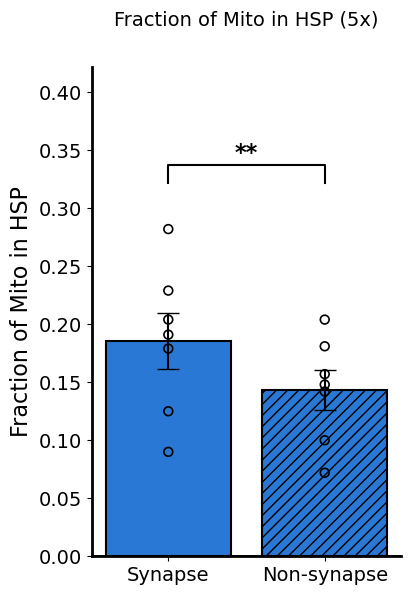


---------- STATS ----------
log_MB_syn_odds_ratio
  W statistic = 0.8954
  p-value     = 0.3039
  → Data look approximately normal

log_MB_non_syn_odds_ratio
  W statistic = 0.9838
  p-value     = 0.9760
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.6497
p-value   = 0.4359
→ Variances are not significantly different

log_MB_syn_odds_ratio
  W statistic = 0.8954
  p-value     = 0.3039
  → Data look approximately normal

log_MB_non_syn_odds_ratio
  W statistic = 0.9838
  p-value     = 0.9760
  → Data look approximately normal

Paired t-test
t statistic = 0.9319
p-value     = 0.3873
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.1429
  Effect size: small

group: Synapse, mean: 0.5800510517719878, sem: 0.18768006202700852
group: Non-synapse, mean: 0.4854327626212121, sem: 0.10417953494641737


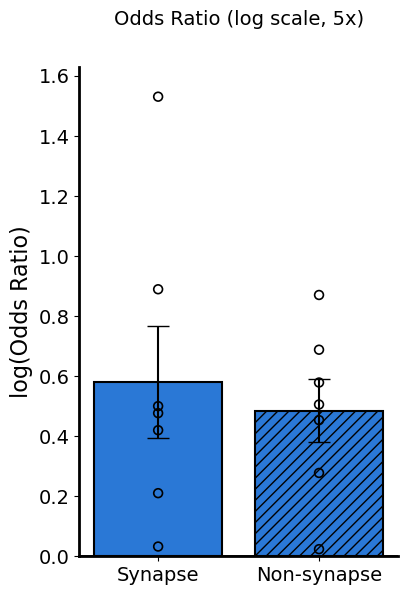


---------- STATS ----------
MB_syn_enrichment
  W statistic = 0.7543
  p-value     = 0.0141
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.9860
  p-value     = 0.9833
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.7880
p-value   = 0.3922
→ Variances are not significantly different

MB_syn_enrichment
  W statistic = 0.7543
  p-value     = 0.0141
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.9860
  p-value     = 0.9833
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 12.0000
p-value     = 0.8125
→ No significant difference detected

  Matched-pairs rank-biserial r = -0.1429
  Effect size: small

group: Synapse, mean: 1.5521428571428573, sem: 0.24616897299478285
group: Non-synapse, mean: 1.4261428571428572, sem: 0.09341699360329225


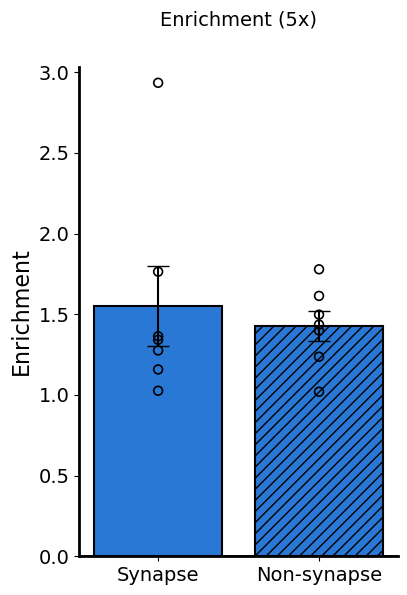

In [11]:
paired_labels = ['Synapse', 'Non-synapse']
paired_color = '#2a78d6'
paired_pattern = ['', '///']  # solid = synapse, striped = non-synapse (consistent with earlier figures)

# 5x only, per request -- not pooled across condition
df_5x = df_separator(pooled)['5x'].copy()

# log(OR) columns -- see markdown above for why OR specifically needs the log scale
df_5x['log_MB_syn_odds_ratio']     = np.log(df_5x['MB_syn_odds_ratio'])
df_5x['log_MB_non_syn_odds_ratio'] = np.log(df_5x['MB_non_syn_odds_ratio'])

# Figure 1: Fraction of HSP in Mito
fast_plotter(
    ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito'],
    df=df_5x, ylabel='Fraction of HSP in Mito', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of HSP in Mito (5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 2: Fraction of Mito in HSP
fast_plotter(
    ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP'],
    df=df_5x, ylabel='Fraction of Mito in HSP', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of Mito in HSP (5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 3: Odds ratio (log scale)
fast_plotter(
    ['log_MB_syn_odds_ratio', 'log_MB_non_syn_odds_ratio'],
    df=df_5x, ylabel='log(Odds Ratio)', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Odds Ratio (log scale, 5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 4: Enrichment
fast_plotter(
    ['MB_syn_enrichment', 'MB_non_syn_enrichment'],
    df=df_5x, ylabel='Enrichment', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Enrichment (5x)', figsize=(4, 6), paired=True, quietStats=False,
)



---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9132
  p-value     = 0.2343
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.6657
  p-value     = 0.0004
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 7.0982
p-value   = 0.0142
→ Variances differ significantly

MB_syn_fraction of HSP in Mito
  W statistic = 0.9132
  p-value     = 0.2343
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.6657
  p-value     = 0.0004
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 30.0000
p-value     = 0.5186
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.2308
  Effect size: small

group: Synapse, mean: 0.21175, sem: 0.02666745974199472
group: Non-synapse, mean: 0.21450000000000002, sem: 0.009976107821827472


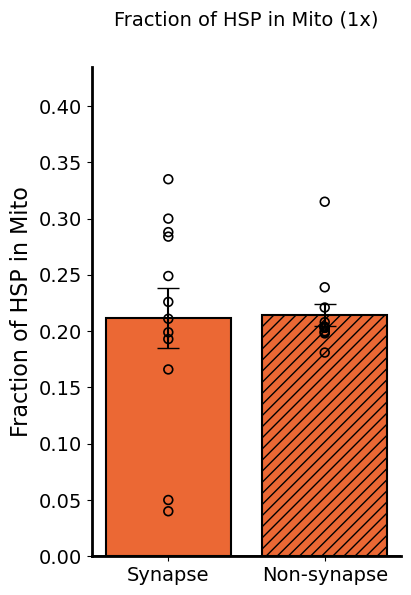


---------- STATS ----------
MB_syn_fraction of Mito in HSP
  W statistic = 0.7853
  p-value     = 0.0064
  → Significant deviation from normality

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.8960
  p-value     = 0.1407
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.9557
p-value   = 0.3389
→ Variances are not significantly different

MB_syn_fraction of Mito in HSP
  W statistic = 0.7853
  p-value     = 0.0064
  → Significant deviation from normality

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.8960
  p-value     = 0.1407
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 17.0000
p-value     = 0.0923
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.5641
  Effect size: large

group: Synapse, mean: 0.16166666666666665, sem: 0.026283228127611743
group: Non-synapse, mean: 0.13533333333333333, sem: 0.012361556568979524


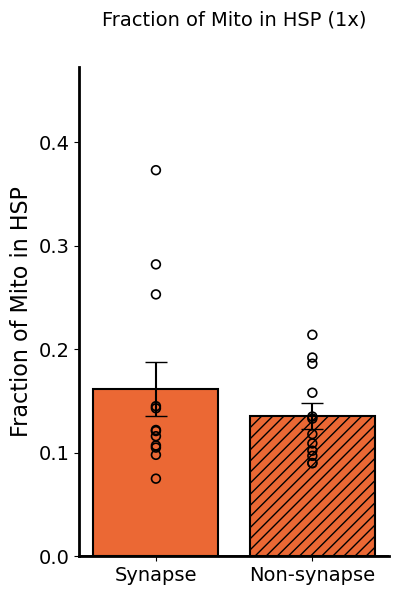


---------- STATS ----------
log_MB_syn_odds_ratio
  W statistic = 0.8112
  p-value     = 0.0126
  → Significant deviation from normality

log_MB_non_syn_odds_ratio
  W statistic = 0.8644
  p-value     = 0.0556
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.1261
p-value   = 0.7259
→ Variances are not significantly different

log_MB_syn_odds_ratio
  W statistic = 0.8112
  p-value     = 0.0126
  → Significant deviation from normality

log_MB_non_syn_odds_ratio
  W statistic = 0.8644
  p-value     = 0.0556
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 18.0000
p-value     = 0.1099
→ No significant difference detected

  Matched-pairs rank-biserial r = -0.5385
  Effect size: large

group: Synapse, mean: 0.40042537124142114, sem: 0.04292067941532012
group: Non-synapse, mean: 0.4585821394636733, sem: 0.04705039836498093


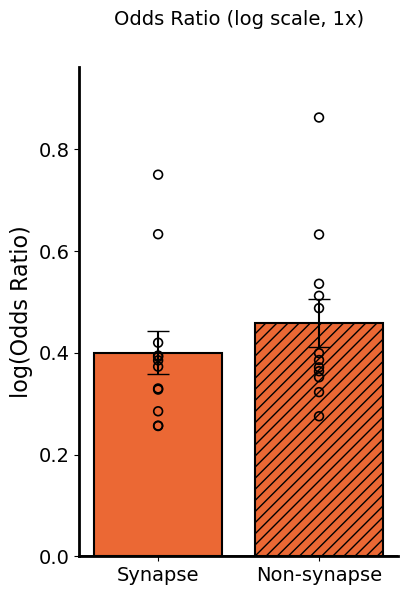


---------- STATS ----------
MB_syn_enrichment
  W statistic = 0.6491
  p-value     = 0.0003
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.8307
  p-value     = 0.0214
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 0.0273
p-value   = 0.8702
→ Variances are not significantly different

MB_syn_enrichment
  W statistic = 0.6491
  p-value     = 0.0003
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.8307
  p-value     = 0.0214
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 25.0000
p-value     = 0.3013
→ No significant difference detected

  Matched-pairs rank-biserial r = -0.3590
  Effect size: medium

group: Synapse, mean: 1.3458333333333332, sem: 0.0639175407865636
group: Non-synapse, mean: 1.3970833333333335, sem: 0.04391287143626318


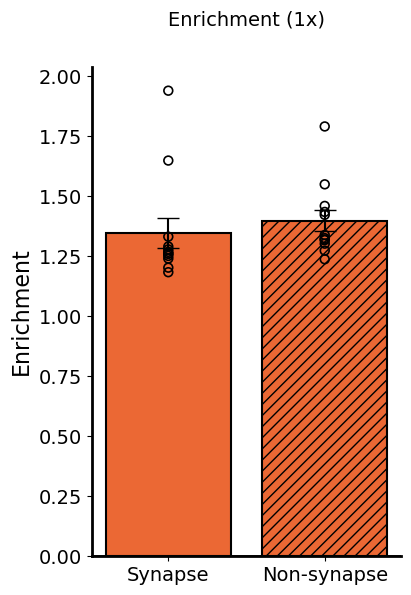

In [12]:
paired_labels = ['Synapse', 'Non-synapse']
paired_color = '#eb6834'
paired_pattern = ['', '///']  # solid = synapse, striped = non-synapse (consistent with earlier figures)

# 5x only, per request -- not pooled across condition
df_5x = df_separator(pooled)['1x'].copy()

# log(OR) columns -- see markdown above for why OR specifically needs the log scale
df_5x['log_MB_syn_odds_ratio']     = np.log(df_5x['MB_syn_odds_ratio'])
df_5x['log_MB_non_syn_odds_ratio'] = np.log(df_5x['MB_non_syn_odds_ratio'])

# Figure 1: Fraction of HSP in Mito
fast_plotter(
    ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito'],
    df=df_5x, ylabel='Fraction of HSP in Mito', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of HSP in Mito (1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 2: Fraction of Mito in HSP
fast_plotter(
    ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP'],
    df=df_5x, ylabel='Fraction of Mito in HSP', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of Mito in HSP (1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 3: Odds ratio (log scale)
fast_plotter(
    ['log_MB_syn_odds_ratio', 'log_MB_non_syn_odds_ratio'],
    df=df_5x, ylabel='log(Odds Ratio)', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Odds Ratio (log scale, 1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 4: Enrichment
fast_plotter(
    ['MB_syn_enrichment', 'MB_non_syn_enrichment'],
    df=df_5x, ylabel='Enrichment', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Enrichment (1x)', figsize=(4, 6), paired=True, quietStats=False,
)


## Same 4 metrics, 5x and 1x side by side

Four bars per figure: `5x syn`, `5x non-syn`, `1x syn`, `1x non-syn` — 5x and 1x in different colors, synapse/non-synapse distinguished by solid/striped as before.

**Why this can't just be `fast_plotter(..., paired=True/False)`:** with 4 groups, `fast_plotter` picks *one* test for the whole set. `paired=True` would run Friedman (repeated-measures), which assumes all 4 values per row come from the same subject — untrue here, since 5x and 1x are different animals. `paired=False` would run Kruskal-Wallis, which assumes all 4 groups are fully independent — also wrong, since syn/non-syn *are* matched within each animal. The real structure is mixed, so the four comparisons below are computed directly instead, and only these four are tested (not all 6 possible pairs — e.g. `5x syn` vs `1x non-syn` doesn't answer a meaningful question here and would just add multiple-comparison noise):

- **`5x syn` vs `5x non-syn`** — paired (Wilcoxon signed-rank), same 5x animals.
- **`1x syn` vs `1x non-syn`** — paired (Wilcoxon signed-rank), same 1x animals.
- **`5x syn` vs `1x syn`** — unpaired (Mann-Whitney U), different animals, same compartment.
- **`5x non-syn` vs `1x non-syn`** — unpaired (Mann-Whitney U), different animals, same compartment.

**Known limitation (accepted for this preliminary analysis):** the unpaired 5x-vs-1x comparisons use region/hemisphere rows as the unit of analysis (n=7 vs n=12), not independent animals (true n=2 vs n=2 — 5x is almost entirely one animal, brain4, plus a single row from brain3; 1x is brain1 and brain2, 6 rows each). This is a conscious simplification given the small sample available right now, not an oversight — see the earlier discussion in this notebook/analysis for the fully animal-aggregated version if a stricter comparison is needed later.

group: 5x syn, mean: 0.2698571428571429, sem: 0.02787166898434303
group: 5x non-syn, mean: 0.21257142857142858, sem: 0.022108883307133252
group: 1x syn, mean: 0.21175, sem: 0.02666745974199472
group: 1x non-syn, mean: 0.21450000000000002, sem: 0.009976107821827472

--- Fraction of HSP in Mito ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9025
  p-value     = 0.3467
  → Data look approximately normal

5x non-syn
  W statistic = 0.9849
  p-value     = 0.9799
  → Data look approximately normal

Paired t-test
t statistic = 2.8355
p-value     = 0.0297
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.9132
  p-value     = 0.2343
  → Data look approximately normal

1x non-syn
  W statistic = 0.6657
  p-value     = 0.0004
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 30.0000
p-value     = 0.5186
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5x syn
  W st

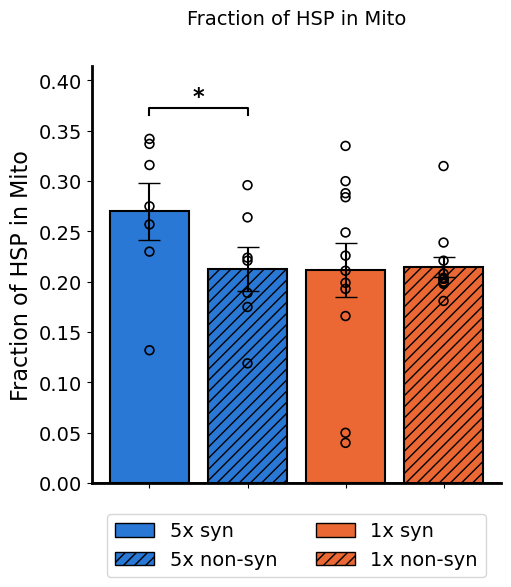

group: 5x syn, mean: 0.18571428571428572, sem: 0.02410267154300958
group: 5x non-syn, mean: 0.14342857142857143, sem: 0.01709616657513098
group: 1x syn, mean: 0.16166666666666665, sem: 0.026283228127611743
group: 1x non-syn, mean: 0.13533333333333333, sem: 0.012361556568979524

--- Fraction of Mito in HSP ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9806
  p-value     = 0.9623
  → Data look approximately normal

5x non-syn
  W statistic = 0.9663
  p-value     = 0.8704
  → Data look approximately normal

Paired t-test
t statistic = 5.5013
p-value     = 0.0015
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.7853
  p-value     = 0.0064
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8960
  p-value     = 0.1407
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 17.0000
p-value     = 0.0923
→ No significant difference detected

Unpaired (5x vs 1x), synapse


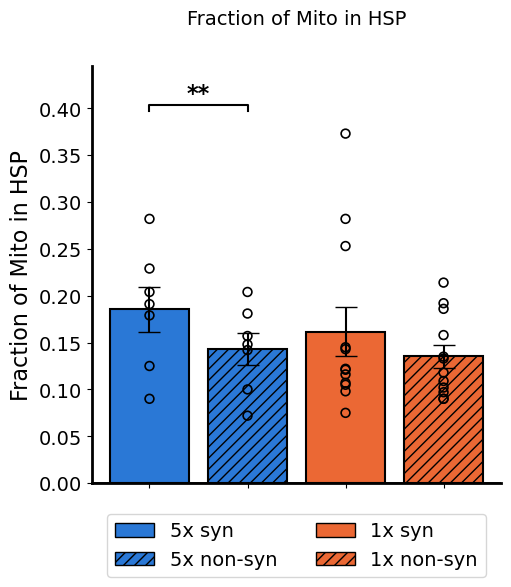

group: 5x syn, mean: 0.5800510517719878, sem: 0.18768006202700852
group: 5x non-syn, mean: 0.4854327626212121, sem: 0.10417953494641737
group: 1x syn, mean: 0.40042537124142114, sem: 0.04292067941532012
group: 1x non-syn, mean: 0.4585821394636733, sem: 0.04705039836498093

--- Odds Ratio (log scale) ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.8954
  p-value     = 0.3039
  → Data look approximately normal

5x non-syn
  W statistic = 0.9838
  p-value     = 0.9760
  → Data look approximately normal

Paired t-test
t statistic = 0.9319
p-value     = 0.3873
→ No significant difference detected

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.8112
  p-value     = 0.0126
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8644
  p-value     = 0.0556
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 18.0000
p-value     = 0.1099
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5x syn
  

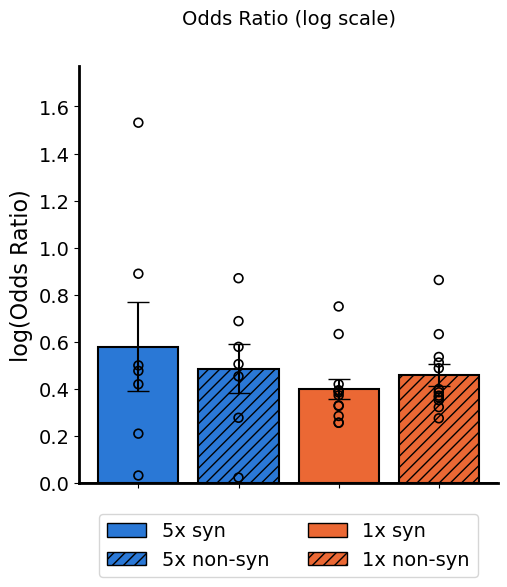

group: 5x syn, mean: 1.5521428571428573, sem: 0.24616897299478285
group: 5x non-syn, mean: 1.4261428571428572, sem: 0.09341699360329225
group: 1x syn, mean: 1.3458333333333332, sem: 0.0639175407865636
group: 1x non-syn, mean: 1.3970833333333335, sem: 0.04391287143626318

--- Enrichment ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.7543
  p-value     = 0.0141
  → Significant deviation from normality

5x non-syn
  W statistic = 0.9860
  p-value     = 0.9833
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 12.0000
p-value     = 0.8125
→ No significant difference detected

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.6491
  p-value     = 0.0003
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8307
  p-value     = 0.0214
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 25.0000
p-value     = 0.3013
→ No significant difference detected

Unpaired (5x vs 1x), synaps

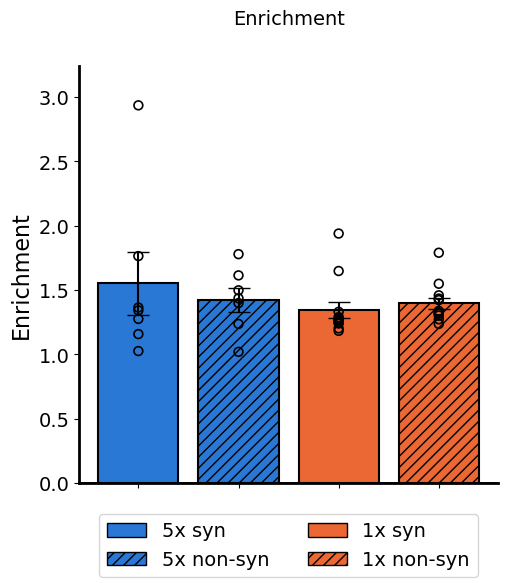

<Axes: title={'center': 'Enrichment'}, ylabel='Enrichment'>

In [13]:
def plot_condition_compartment(metric_syn, metric_non_syn, ylabel, title,
                                df_5x, df_1x, log_transform=False, figsize=(5, 6)):
    x5_syn = df_5x[metric_syn].to_numpy(dtype=float)
    x5_non = df_5x[metric_non_syn].to_numpy(dtype=float)
    x1_syn = df_1x[metric_syn].to_numpy(dtype=float)
    x1_non = df_1x[metric_non_syn].to_numpy(dtype=float)

    if log_transform:
        x5_syn, x5_non, x1_syn, x1_non = np.log(x5_syn), np.log(x5_non), np.log(x1_syn), np.log(x1_non)

    groups = [x5_syn, x5_non, x1_syn, x1_non]
    labels = ['5x syn', '5x non-syn', '1x syn', '1x non-syn']
    colors = ['#2a78d6', '#2a78d6', '#eb6834', '#eb6834']   # 5x = blue, 1x = orange
    patterns = ['', '///', '', '///']                        # solid = synapse, striped = non-synapse

    # plot_bars_with_sem3_test (not plot_bars_with_sem3) so title/legend styling
    # matches the density_HSP/density_Mito figures above exactly -- same function,
    # same title_font_size/pad, and a legend instead of x-tick text labels.
    ax = plot_bars_with_sem3_test(groups, labels=labels, ylabel=ylabel,
                                   bar_color=colors, pattern=patterns, figsize=figsize,
                                   title=title, title_font_size=14, legend=True)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.label.set_size(16)

    print(f'\n--- {title} ---')
    # two_group_test (plotter.py) -- same normality-gated test selection fast_plotter
    # uses internally (paired t-test/Wilcoxon for paired, independent t-test/Mann-Whitney
    # for unpaired), so this function can't silently drift from what fast_plotter would
    # choose for the same two groups. Previously this hardcoded wilcoxon_test/
    # mannwhitneyu_test unconditionally, which could disagree with fast_plotter's
    # (correct) choice on data that passes normality.
    print('Paired (within 5x): synapse vs non-synapse')
    sig_5x, p_5x = two_group_test([x5_syn, x5_non], labels=['5x syn', '5x non-syn'], paired=True)
    print('Paired (within 1x): synapse vs non-synapse')
    sig_1x, p_1x = two_group_test([x1_syn, x1_non], labels=['1x syn', '1x non-syn'], paired=True)
    print('Unpaired (5x vs 1x), synapse')
    sig_syn, p_syn = two_group_test([x5_syn, x1_syn], labels=['5x syn', '1x syn'], paired=False)
    print('Unpaired (5x vs 1x), non-synapse')
    sig_non, p_non = two_group_test([x5_non, x1_non], labels=['5x non-syn', '1x non-syn'], paired=False)

    # only these 4 biologically meaningful comparisons are tested/annotated --
    # see markdown above for why the other 2 possible cross-pairs are skipped
    candidates = [(0, 1, sig_5x, p_5x), (2, 3, sig_1x, p_1x),
                  (0, 2, sig_syn, p_syn), (1, 3, sig_non, p_non)]
    sig_pairs = [(i1, i2, p) for i1, i2, sig, p in candidates if sig]

    data_max = max(g.max() for g in groups)
    data_min = min(g.min() for g in groups)
    span = (data_max - data_min) if data_max > data_min else 1.0
    bar_step = span * 0.08
    for k, (i1, i2, p) in enumerate(sig_pairs):
        y = data_max + bar_step + k * bar_step
        add_sig_bar(ax, i1, i2, y, bar_step * 0.25, p_to_stars(p))

    bottom = data_min - span * 0.1 if data_min < 0 else 0
    top = data_max + bar_step * (len(sig_pairs) + 2)
    ax.set_ylim(bottom, top)
    plt.show()
    return ax


df_5x = df_separator(pooled)['5x'].copy()
df_1x = df_separator(pooled)['1x'].copy()

plot_condition_compartment(
    'MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito',
    'Fraction of HSP in Mito', 'Fraction of HSP in Mito', df_5x, df_1x,
)

plot_condition_compartment(
    'MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP',
    'Fraction of Mito in HSP', 'Fraction of Mito in HSP', df_5x, df_1x,
)

plot_condition_compartment(
    'MB_syn_odds_ratio', 'MB_non_syn_odds_ratio',
    'log(Odds Ratio)', 'Odds Ratio (log scale)', df_5x, df_1x, log_transform=True,
)

plot_condition_compartment(
    'MB_syn_enrichment', 'MB_non_syn_enrichment',
    'Enrichment', 'Enrichment', df_5x, df_1x,
)
